# QQ-Plot

✔ Basic QQ-Plot

✔ QQ-Plot vs. Custom Distribution

✔ QQ-Plot with Confidence Bands (Advanced)

✔ QQ-Plot Grid for Multiple Columns

✔ QQ-Plot with Heavy-Tailed Distribution Comparison

✔ Fully Styled Professional Version

## Basic QQ-Plot (Normal Q–Q)

In [2]:
! pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.5 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 38.5 MB/s eta 0:00:00
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)


c:\Users\Black Parrot\miniconda3\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


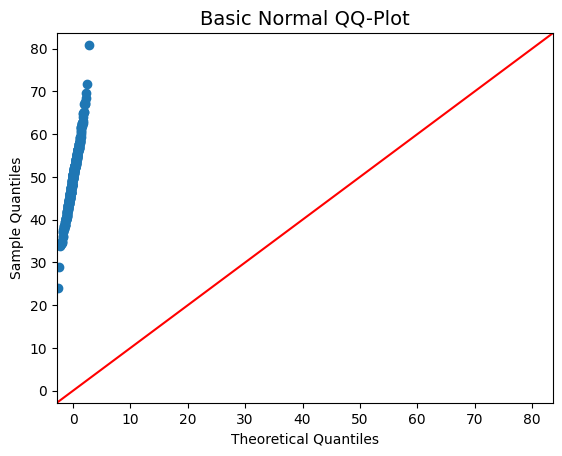

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Example data
np.random.seed(42)
data = np.random.normal(loc=50, scale=8, size=300)

fig = sm.qqplot(data, line='45', marker='o', color='darkblue')
plt.title("Basic Normal QQ-Plot", fontsize=14)
plt.show()


## QQ-Plot Against Any Custom Distribution

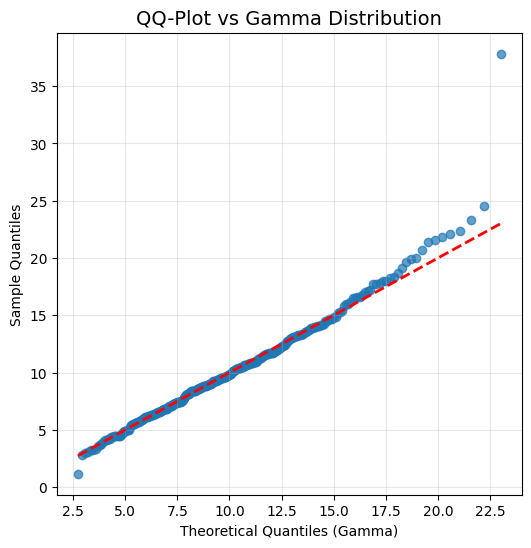

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm

np.random.seed(42)
data = st.gamma(a=5, scale=2).rvs(300)

# Fit gamma distribution to data
params = st.gamma.fit(data)

# Create theoretical quantiles
theoretical_quantiles = st.gamma(*params).ppf(np.linspace(0.01, 0.99, len(data)))
sample_quantiles = np.sort(data)

plt.figure(figsize=(6, 6))
plt.scatter(theoretical_quantiles, sample_quantiles, alpha=0.7)
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--', lw=2)

plt.xlabel("Theoretical Quantiles (Gamma)")
plt.ylabel("Sample Quantiles")
plt.title("QQ-Plot vs Gamma Distribution", fontsize=14)
plt.grid(alpha=0.3)
plt.show()


## Advanced QQ-Plot with 95% Confidence Bands

This is high-level statistics and extremely useful.


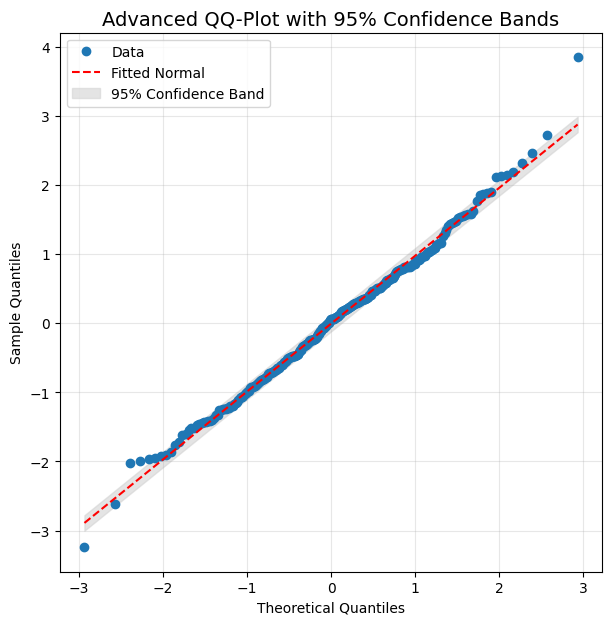

In [5]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(42)
data = np.random.normal(size=300)
data_sorted = np.sort(data)

# Theoretical quantiles
n = len(data)
prob = (np.arange(1, n + 1) - 0.5) / n
z = st.norm.ppf(prob)

# Fit normal distribution
mu, sigma = np.mean(data), np.std(data)

# Confidence intervals
se = (sigma / np.sqrt(n)) * st.norm.ppf(0.975)
lower = z * sigma - se + mu
upper = z * sigma + se + mu

plt.figure(figsize=(7, 7))
plt.plot(z, data_sorted, "o", label="Data")
plt.plot(z, mu + sigma * z, "r--", label="Fitted Normal")
plt.fill_between(z, lower, upper, color='lightgray', alpha=0.6,
                 label="95% Confidence Band")

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("Advanced QQ-Plot with 95% Confidence Bands", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Grid of QQ-Plots for Multiple Columns

Useful for large datasets.

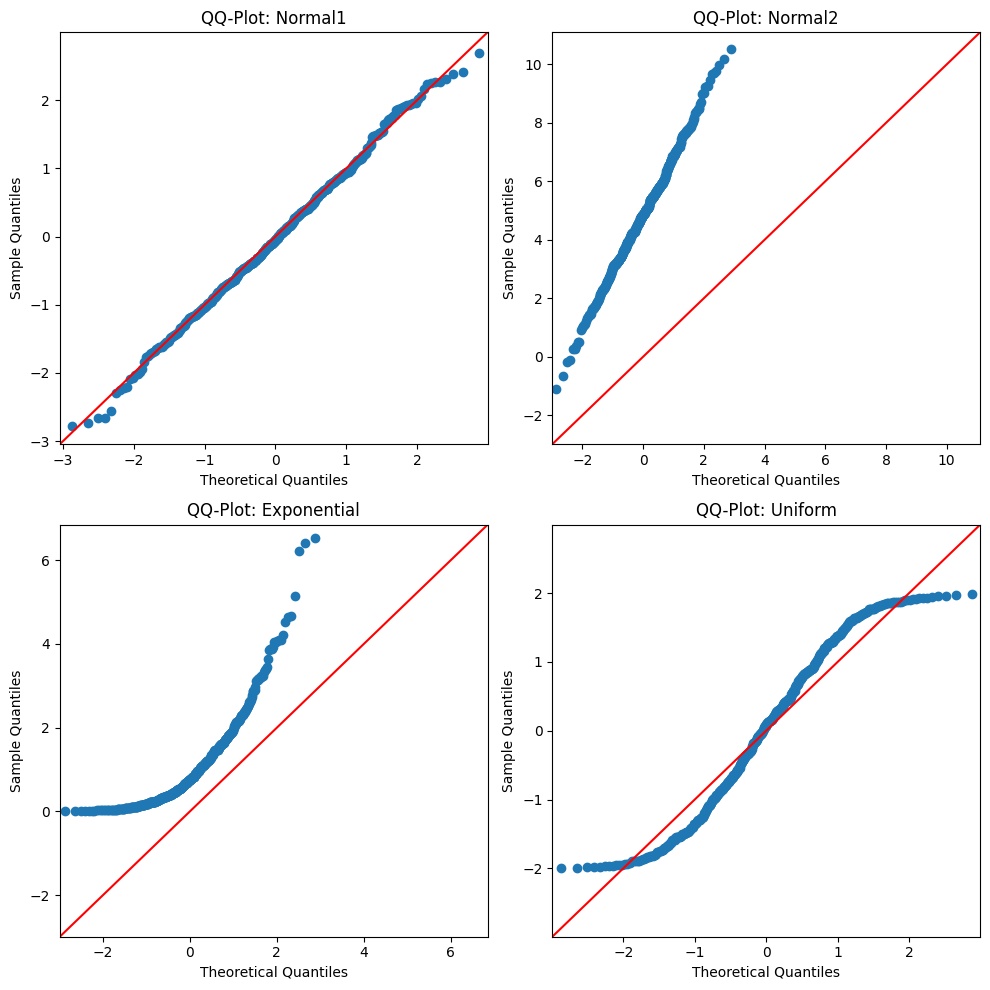

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

np.random.seed(0)

df = pd.DataFrame({
    "Normal1": np.random.normal(0, 1, 500),
    "Normal2": np.random.normal(5, 2, 500),
    "Exponential": np.random.exponential(1, 500),
    "Uniform": np.random.uniform(-2, 2, 500)
})

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, col in zip(axes.flatten(), df.columns):
    sm.qqplot(df[col], line='45', ax=ax)
    ax.set_title(f"QQ-Plot: {col}")

plt.tight_layout()
plt.show()


## QQ-Plot Against a Heavy-Tailed Distribution (Student-t)

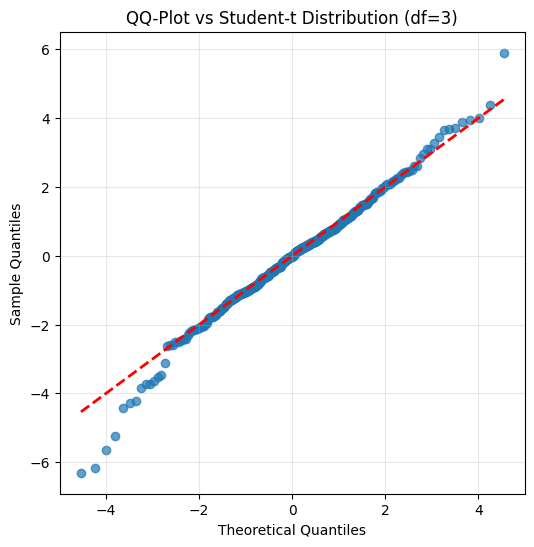

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

np.random.seed(42)
data = st.t(df=3).rvs(500)  # heavy-tailed

# Theoretical quantiles
prob = np.linspace(0.01, 0.99, len(data))
theor = st.t(df=3).ppf(prob)

plt.figure(figsize=(6, 6))
plt.scatter(theor, np.sort(data), alpha=0.7)
plt.plot(theor, theor, 'r--', lw=2)

plt.title("QQ-Plot vs Student-t Distribution (df=3)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(alpha=0.3)
plt.show()


## Professional Styled QQ-Plot (Presentation-Ready)

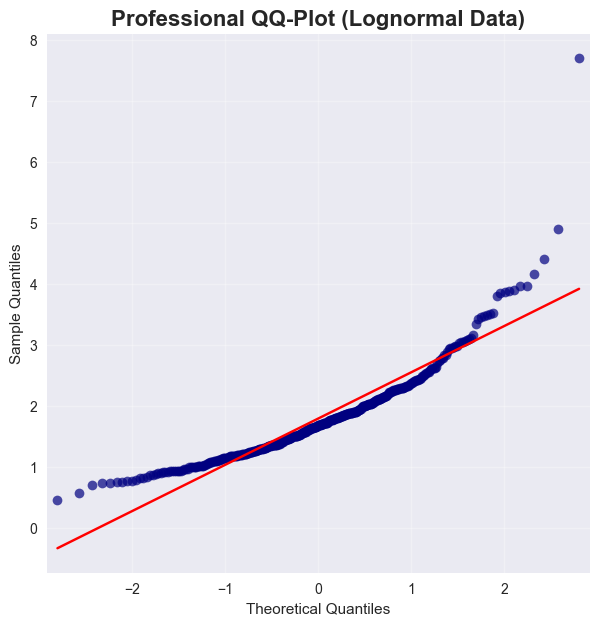

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Data
np.random.seed(42)
data = np.random.lognormal(mean=0.5, sigma=0.4, size=400)

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(7, 7))
sm.qqplot(data, line='s', ax=ax, markerfacecolor='navy',
          markeredgecolor='white', alpha=0.7)

ax.set_title("Professional QQ-Plot (Lognormal Data)", fontsize=16, weight="bold")
ax.grid(alpha=0.3)

plt.show()
